In [5]:
import os
from pathlib import Path
os.environ["CUDA_VISIBLE_DEVICES"] = "3"


import torch
# torch.cuda.init()
print(os.environ.get("CUDA_VISIBLE_DEVICES"))
!source /home/jupyter/Mrigi/env.sh
hf_token = os.environ.get("HF_TOKEN")


torch.cuda.set_device(0)
import json

from langchain.embeddings import HuggingFaceEmbeddings
from langchain.embeddings import SentenceTransformerEmbeddings
from langchain.vectorstores import FAISS
from langchain.prompts import ChatPromptTemplate
from langchain.llms import HuggingFacePipeline
from langchain.chains import LLMChain
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline



3


In [6]:
from pydantic import BaseModel, Field
from typing import Optional, Union
from datetime import datetime
from tqdm import tqdm

In [7]:
!nvidia-smi

Tue Feb 24 12:37:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.119.02             Driver Version: 580.119.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5000               Off |   00000000:31:00.0 Off |                  Off |
| 30%   36C    P0             65W /  230W |       0MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:

!kill -9 3395693


/bin/bash: line 0: kill: (3395693) - No such process


In [9]:
# ---------- Step 1: Load and Process the JSON Records ----------
# # Load JSON records from file
# with open('filtered_records_subset_100.json', 'r') as file:
#     filtered_records = json.load(file)

In [10]:
# Process each record: extract paragraphs with "Experimental" supersection,
# concatenate them, and append DOI info.
# documents = []
# metadata = []

In [11]:
# Process records into documents
# documents = []
# metadata = []

# for record in filtered_records:
#     doi = record.get("doi", "Unknown DOI")
    
#     # Add abstract as a separate document
#     abstract_text = record.get("abstract", "").strip()
#     if abstract_text:
#         combined_text = f"{abstract_text}\n\nThis information is from DOI: {doi}"
#         documents.append(combined_text)
#         metadata.append({"doi": doi, "source": "abstract"})
    
#     # Add each paragraph as a separate document
#     for para in record.get("paragraphs", []):
#         paragraph_text = para.get("text", "").strip()
#         if paragraph_text:
#             combined_text = f"{paragraph_text}\n\nThis information is from DOI: {doi}"
#             documents.append(combined_text)
#             metadata.append({"doi": doi, "source": "paragraph"})

# print(f"Total documents processed: {len(documents)}")

In [12]:
# for doc in documents:
#     print(doc)
#     print("-"*40)  # Optional: adds a visual separator between different papers


In [13]:
# ---------- Step 2: Prepare Embeddings for the Existing FAISS Index ----------
# Use the same model configuration that was used when the index was created.
# embeddings = HuggingFaceEmbeddings(model_name="allenai/scibert_scivocab_uncased")
embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

/tmp/ipykernel_3920846/2006348050.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")


In [14]:
# ---------- Step 2: Load the Existing Vector Database from Disk ----------
INDEX_DIRECTORY = Path("faiss_index")
INDEX_NAME = "index"
if not INDEX_DIRECTORY.exists():
    raise FileNotFoundError(f"Vector index directory '{INDEX_DIRECTORY}' not found.")

# Use allow_dangerous_deserialization=True to load indices saved with pickle-based metadata.
vector_db = FAISS.load_local(
    INDEX_DIRECTORY,
    embeddings,
    index_name=INDEX_NAME,
    allow_dangerous_deserialization=True
)
print(f"Loaded vector database from {INDEX_DIRECTORY} with {vector_db.index.ntotal} vectors")

Loaded vector database from faiss_index with 1474439 vectors


In [15]:
# # Print DOIs for up to the first 50 processed documents
# if not metadata:
#     print("No metadata available. Did you load the records?")
# else:
#     for entry in metadata[:50]:
#         print(entry.get("doi", "Unknown DOI"))

In [16]:
# ---------- Step 3: Use the Vector DB in a RAG Pipeline ----------
# Define your query.
# query = "How is hierarchical ZSM-5 synthesized?"
# query = "What is the best way to synthesize ZSM-5 that is hierarchical?"
# query = "How is Silicalite-1 synthesized?"
query = "How can you study the effect of nature of silica source on the purity of template-free ZSM-5?"


In [17]:
# Retrieve top k relevant documents (papers) from the vector database.
retrieved_docs = vector_db.similarity_search(query, k=4)
context_text = "\n\n".join([doc.page_content for doc in retrieved_docs])

In [18]:
# print(embeddings.embed_query("Silicalite-1 synthesis"))
# print(embeddings.embed_documents(["test text 1", "test text 2"]))


In [19]:
context_text

'For ZSM-5, the best results were obtained with an undiluted synthesis solution, in contrast to silicalite. At 180 degC and 4 h of reaction time, the synthesis procedure for ZSM-5 proved to be highly reproducible (entries 13-16) in terms of layer thickness.\n\nThis information is from DOI: 10.1016/j.snb.2016.05.133\n\nFor ZSM-5, the best results were obtained with an undiluted synthesis solution, in contrast to silicalite. At 180 degC and 4 h of reaction time, the synthesis procedure for ZSM-5 proved to be highly reproducible (entries 13-16) in terms of layer thickness.\n\nThis information is from DOI: 10.1016/j.snb.2016.05.133\n\nFinally, the Si/Al ratios of the optimized ZSM-5 samples vary between 59-63. Considering that 15 mol % of SiO2 was in the silicalite-1 seeds and thus 85 mol % of SiO2 in the ZSM-5 phase, the actual Si/Al ratio in the ZSM-5 phase varied between 69-74. This shows that Al is fully incorporated into the ZSM-5 phase.\n\nThis information is from DOI: 10.1002/cctc.2

In [20]:
# RAG prompt template
RAG_PROMPT = """
Answer the question based only on the following context:
{context}
Question: {question}
Provide a detailed answer.
Provide which DOI the answer is retrieved from.
"""



In [21]:
rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)
prompt = rag_prompt.format(context=context_text, question=query)

In [22]:
# ---------- Step 4: Generate an Answer Using an Open-Source LLM ----------
# Setup the open source LLM using Mistral (ensure you have the model or access to it)
model_name = "mistralai/Mistral-7B-Instruct-v0.1"

In [23]:
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, use_fast=False, use_auth_token=hf_token)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [24]:
from transformers.models.auto.configuration_auto import CONFIG_MAPPING
print("Supported model types:", list(CONFIG_MAPPING.keys()))

Supported model types: ['albert', 'align', 'altclip', 'audio-spectrogram-transformer', 'autoformer', 'bark', 'bart', 'beit', 'bert', 'bert-generation', 'big_bird', 'bigbird_pegasus', 'biogpt', 'bit', 'blenderbot', 'blenderbot-small', 'blip', 'blip-2', 'bloom', 'bridgetower', 'bros', 'camembert', 'canine', 'chinese_clip', 'clap', 'clip', 'clipseg', 'code_llama', 'codegen', 'conditional_detr', 'convbert', 'convnext', 'convnextv2', 'cpmant', 'ctrl', 'cvt', 'data2vec-audio', 'data2vec-text', 'data2vec-vision', 'deberta', 'deberta-v2', 'decision_transformer', 'deformable_detr', 'deit', 'deta', 'detr', 'dinat', 'dinov2', 'distilbert', 'donut-swin', 'dpr', 'dpt', 'efficientformer', 'efficientnet', 'electra', 'encodec', 'encoder-decoder', 'ernie', 'ernie_m', 'esm', 'falcon', 'flaubert', 'flava', 'fnet', 'focalnet', 'fsmt', 'funnel', 'git', 'glpn', 'gpt-sw3', 'gpt2', 'gpt_bigcode', 'gpt_neo', 'gpt_neox', 'gpt_neox_japanese', 'gptj', 'gptsan-japanese', 'graphormer', 'groupvit', 'hubert', 'ibert'

In [25]:
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", trust_remote_code=True, use_auth_token=hf_token, torch_dtype=torch.float16)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [26]:
hf_pipeline = pipeline("text-generation", model=model, tokenizer=tokenizer, max_length=10000)

In [27]:
# Wrap the Hugging Face pipeline with LangChain's HuggingFacePipeline interface.
rag_llm = HuggingFacePipeline(pipeline=hf_pipeline)



/tmp/ipykernel_3920846/4067646612.py:2: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.
  rag_llm = HuggingFacePipeline(pipeline=hf_pipeline)


In [28]:
# Generate the answer based on the prompt that includes retrieved context.
# response_text = rag_llm(prompt)
# print("Response:")
# print(response_text)

In [29]:
import random

def get_unique_dois_with_titles(vector_db, limit=200, random_sample=True):
    """Extract unique DOIs and their associated titles from the vector store
    
    Args:
        vector_db: FAISS vector database
        limit: Number of DOIs to return (default 200)
        random_sample: If True, randomly sample from all DOIs; if False, take first N
    """
    seen_dois = set()
    doi_titles = []
    
    # Get all documents
    all_docs = vector_db.similarity_search("", k=vector_db.index.ntotal)
    
    for doc in all_docs:
        # Extract DOI from the document content
        content = doc.page_content
        metadata = doc.metadata
        
        # Find DOI in the content (it's typically at the end of each document)
        if "This information is from DOI:" in content:
            doi = content.split("This information is from DOI:")[-1].strip()
            
            if doi not in seen_dois:
                seen_dois.add(doi)
                # Look for title in metadata or content
                title = metadata.get('title', 'Title not found')
                doi_titles.append({'doi': doi, 'title': title})
    
    # Apply random sampling if requested
    if random_sample and len(doi_titles) > limit:
        random.seed(42)  # Set seed for reproducibility
        doi_titles = random.sample(doi_titles, limit)
    else:
        doi_titles = doi_titles[:limit]
    
    return doi_titles

# Get 200 randomly sampled unique DOIs with titles (we'll subset 100 from these)
unique_entries = get_unique_dois_with_titles(vector_db, limit=200, random_sample=True)
print(f"\nRandomly sampled {len(unique_entries)} unique DOIs from the database")
print(f"First 5 samples:")
for entry in unique_entries[:5]:
    print(f"\nDOI: {entry['doi']}")
    print(f"Title: {entry['title']}")
print("\n" + "="*80)


Randomly sampled 200 unique DOIs from the database
First 5 samples:

DOI: 10.1016/j.jmr.2015.12.009
Title: Title not found

DOI: 10.1038/s41467-017-01765-0
Title: Title not found

DOI: 10.1039/d1ta10008d
Title: Title not found

DOI: 10.1002/anie.200219624
Title: Title not found

DOI: 10.1021/jp205312k
Title: Title not found



In [30]:
# Load the filtered records that contain title information
with open('filtered_records_on_zeolite.json', 'r') as f:
    filtered_records = json.load(f)

# Get DOIs from our vector database
vector_dois = {entry['doi'] for entry in unique_entries}

# Create enriched records matching vector DOIs (DEDUPLICATED by DOI)
# Only include records that have BOTH a valid title AND a valid DOI
seen_dois = set()
all_enriched = []
for record in filtered_records:
    doi = record.get('doi')
    title = record.get('title', '')
    if doi and title and doi in vector_dois and doi not in seen_dois:
        seen_dois.add(doi)
        all_enriched.append({'doi': doi, 'title': title})

print(f"Total valid DOI-title pairs found: {len(all_enriched)}")

# Build n=200 test set
random.seed(42)
if len(all_enriched) >= 200:
    enriched_200 = random.sample(all_enriched, 200)
else:
    enriched_200 = all_enriched.copy()
    print(f"WARNING: Only {len(enriched_200)} valid pairs found (less than 200)")

# Build n=100 test set (strict subset of the 200 for fair comparison)
random.seed(42)
enriched_100 = random.sample(enriched_200, min(100, len(enriched_200)))

# Save both
for name, records in [("zeolite_papers_100.json", enriched_100), ("zeolite_papers_200.json", enriched_200)]:
    with open(name, 'w') as f:
        json.dump(records, f, indent=2)

print(f"\nn=100 test set: {len(enriched_100)} papers")
print(f"n=200 test set: {len(enriched_200)} papers")
print(f"\nFirst 3 entries (n=100):")
for record in enriched_100[:3]:
    print(f"  Title: {record['title'][:80]}...")
    print(f"  DOI:   {record['doi']}")

Total valid DOI-title pairs found: 189

n=100 test set: 100 papers
n=200 test set: 189 papers

First 3 entries (n=100):
  Title: Zeolitized tuff in environmental friendly production of cementitious material: C...
  DOI:   10.1016/j.conbuildmat.2015.09.035
  Title: Photodimerization of trans-2-styrylpyridine in zeolite cages...
  DOI:   10.1016/s1010-6030(00)00271-9
  Title: Consequence of replacing nitrogen with carbon dioxide as atmosphere on suppressi...
  DOI:   10.1016/j.biortech.2019.122417


## Evaluating Retrieval Accuracy

We'll use the titles as queries and check if the retrieved documents' DOIs match the ground truth DOIs.

**K values:** Top-1, Top-5, Top-10, Top-15, Top-20  
**Test sets:** n=100 and n=200  
**Methods:** FAISS (semantic), BM25 (keyword), Hybrid (BM25 + MMR)

In [31]:
K_VALUES = [1, 5, 10, 15, 20]

def extract_dois_from_docs(docs):
    """Extract DOIs from retrieved LangChain documents."""
    dois = []
    for doc in docs:
        content = doc.page_content
        if "This information is from DOI:" in content:
            doi = content.split("This information is from DOI:")[-1].strip()
            dois.append(doi)
    return dois

def evaluate_retrieval(records, retrieve_fn, method_name="", ks=K_VALUES):
    """Generic retrieval evaluator that works for any retrieval function.
    
    Args:
        records: List of dicts with 'title' and 'doi'
        retrieve_fn: Callable(query, k) -> list of LangChain Documents
        method_name: Label for progress bar
        ks: List of k values to evaluate
    
    Returns:
        Dict with accuracy at each k and total_evaluated
    """
    max_k = max(ks)
    total = 0
    correct = {k: 0 for k in ks}
    
    desc = f"Evaluating {method_name}" if method_name else "Evaluating"
    for record in tqdm(records, desc=desc):
        query = record.get('title')
        true_doi = record.get('doi')
        if not query or not true_doi:
            continue
        total += 1
        
        # Retrieve once at max_k, then slice for each k
        retrieved_docs = retrieve_fn(query, max_k)
        retrieved_dois = extract_dois_from_docs(retrieved_docs)
        
        for k in ks:
            if any(doi == true_doi for doi in retrieved_dois[:k]):
                correct[k] += 1
    
    results = {f'top_{k}': correct[k] / total * 100 for k in ks}
    results['total_evaluated'] = total
    return results

print("Unified evaluation function defined!")
print(f"K values: {K_VALUES}")

Unified evaluation function defined!
K values: [1, 5, 10, 15, 20]


## Setup Retrievers: BM25 and Hybrid (BM25 + MMR)

In [32]:
# Import BM25 retriever
from langchain.retrievers import BM25Retriever

# Initialize BM25 retriever for hybrid search
print("Initializing BM25 retriever...")
all_docs = list(vector_db.docstore._dict.values())
bm25_retriever = BM25Retriever.from_documents(all_docs)
bm25_retriever.k = 10  # Set to retrieve top 10 documents

print(f"BM25 retriever initialized with {len(all_docs)} documents")
print("BM25 retriever ready!")

Initializing BM25 retriever...
BM25 retriever initialized with 1474439 documents
BM25 retriever ready!
BM25 retriever initialized with 1474439 documents
BM25 retriever ready!


In [33]:
def hybrid_search(query: str, vector_db, bm25_retriever, k_total=10, k_bm25=10, k_mmr=10, 
                  mmr_fetch_k=40, mmr_lambda=0.6):
    """
    Performs hybrid retrieval combining BM25 and MMR.
    
    Args:
        query: Search query string
        vector_db: FAISS vector database
        bm25_retriever: BM25 retriever instance
        k_total: Total number of unique documents to return
        k_bm25: Number of documents to retrieve from BM25
        k_mmr: Number of documents to retrieve from MMR
        mmr_fetch_k: Number of candidates for MMR to consider
        mmr_lambda: MMR lambda parameter (0=max diversity, 1=max relevance)
    
    Returns:
        List of unique documents combined from both retrievers
    """
    # Get BM25 results (keyword-based)
    bm25_retriever.k = k_bm25
    bm25_docs = bm25_retriever.get_relevant_documents(query)
    
    # Get MMR results (semantic + diversity)
    mmr_docs = vector_db.max_marginal_relevance_search(
        query,
        k=k_mmr,
        fetch_k=mmr_fetch_k,
        lambda_mult=mmr_lambda
    )
    
    # Combine and deduplicate based on page_content
    seen_contents = set()
    combined_docs = []
    
    # Add BM25 results first (prioritize keyword matches)
    for doc in bm25_docs:
        content_hash = hash(doc.page_content)
        if content_hash not in seen_contents:
            seen_contents.add(content_hash)
            combined_docs.append(doc)
    
    # Add MMR results
    for doc in mmr_docs:
        content_hash = hash(doc.page_content)
        if content_hash not in seen_contents:
            seen_contents.add(content_hash)
            combined_docs.append(doc)
    
    return combined_docs[:k_total]

print("Hybrid search function defined!")

Hybrid search function defined!


In [34]:
# --- Define retrieval functions for each method ---

def faiss_retrieve(query, k):
    """FAISS semantic similarity search."""
    return vector_db.similarity_search(query, k=k)

def bm25_retrieve(query, k):
    """BM25 keyword-based search."""
    bm25_retriever.k = k
    return bm25_retriever.get_relevant_documents(query)

def hybrid_retrieve(query, k):
    """Hybrid: BM25 + MMR combined retrieval."""
    return hybrid_search(query, vector_db, bm25_retriever,
                         k_total=k, k_bm25=k, k_mmr=k,
                         mmr_fetch_k=max(40, k*2), mmr_lambda=0.6)

METHODS = {
    'FAISS': faiss_retrieve,
    'BM25': bm25_retrieve,
    'Hybrid (BM25+MMR)': hybrid_retrieve,
}

METHOD_COLORS = {'FAISS': '#2ecc71', 'BM25': '#e74c3c', 'Hybrid (BM25+MMR)': '#9b59b6'}
METHOD_MARKERS = {'FAISS': 'o', 'BM25': 's', 'Hybrid (BM25+MMR)': 'D'}

print("Retrieval functions defined: faiss_retrieve, bm25_retrieve, hybrid_retrieve")

Retrieval functions defined: faiss_retrieve, bm25_retrieve, hybrid_retrieve


In [35]:
# --- Run all evaluations for n=100 and n=200 ---

all_results = {}  # {(method, n): results_dict}

for n_label, records in [('n=100', enriched_100), ('n=200', enriched_200)]:
    print(f"\n{'='*80}")
    print(f"  EVALUATING ALL METHODS ON {n_label}")
    print(f"{'='*80}")
    for method_name, retrieve_fn in METHODS.items():
        results = evaluate_retrieval(records, retrieve_fn, method_name=f"{method_name} ({n_label})")
        all_results[(method_name, n_label)] = results
        n_eval = results['total_evaluated']
        print(f"\n  {method_name} ({n_label}, evaluated={n_eval}):")
        for k in K_VALUES:
            acc = results[f'top_{k}']
            print(f"    Top-{k:>2}: {acc:5.1f}%  ({int(acc/100*n_eval)}/{n_eval})")

print(f"\n{'='*80}")
print("All evaluations complete!")
print(f"{'='*80}")


  EVALUATING ALL METHODS ON n=100


Evaluating FAISS (n=100): 100%|██████████| 100/100 [00:14<00:00,  7.01it/s]



  FAISS (n=100, evaluated=100):
    Top- 1:  50.0%  (50/100)
    Top- 5:  75.0%  (75/100)
    Top-10:  82.0%  (82/100)
    Top-15:  85.0%  (85/100)
    Top-20:  88.0%  (88/100)


Evaluating BM25 (n=100):   0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_3920846/1449115147.py:10: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  return bm25_retriever.get_relevant_documents(query)
/tmp/ipykernel_3920846/1449115147.py:10: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  return bm25_retriever.get_relevant_documents(query)
Evaluating BM25 (n=100): 100%|██████████| 100/100 [10:27<00:00,  6.28s/it]



  BM25 (n=100, evaluated=100):
    Top- 1:  42.0%  (42/100)
    Top- 5:  58.0%  (57/100)
    Top-10:  69.0%  (69/100)
    Top-15:  71.0%  (71/100)
    Top-20:  72.0%  (72/100)


...


  FAISS (n=200, evaluated=189):
    Top- 1:  43.9%  (83/189)
    Top- 5:  70.4%  (133/189)
    Top-10:  78.3%  (148/189)
    Top-15:  81.0%  (153/189)
    Top-20:  84.1%  (159/189)


Evaluating BM25 (n=200): 100%|██████████| 189/189 [19:31<00:00,  6.20s/it]



  BM25 (n=200, evaluated=189):
    Top- 1:  39.7%  (75/189)
    Top- 5:  55.6%  (105/189)
    Top-10:  63.5%  (120/189)
    Top-15:  67.2%  (127/189)
    Top-20:  68.8%  (130/189)


Evaluating Hybrid (BM25+MMR) (n=200): 100%|██████████| 189/189 [20:09<00:00,  6.40s/it]


  Hybrid (BM25+MMR) (n=200, evaluated=189):
    Top- 1:  39.7%  (75/189)
    Top- 5:  56.6%  (107/189)
    Top-10:  65.1%  (122/189)
    Top-15:  69.8%  (132/189)
    Top-20:  77.8%  (147/189)

All evaluations complete!


## Comprehensive Comparison: FAISS vs BM25 vs Hybrid

Three retrieval methods × two test set sizes (n=100, n=200) × five K values (1, 5, 10, 15, 20)

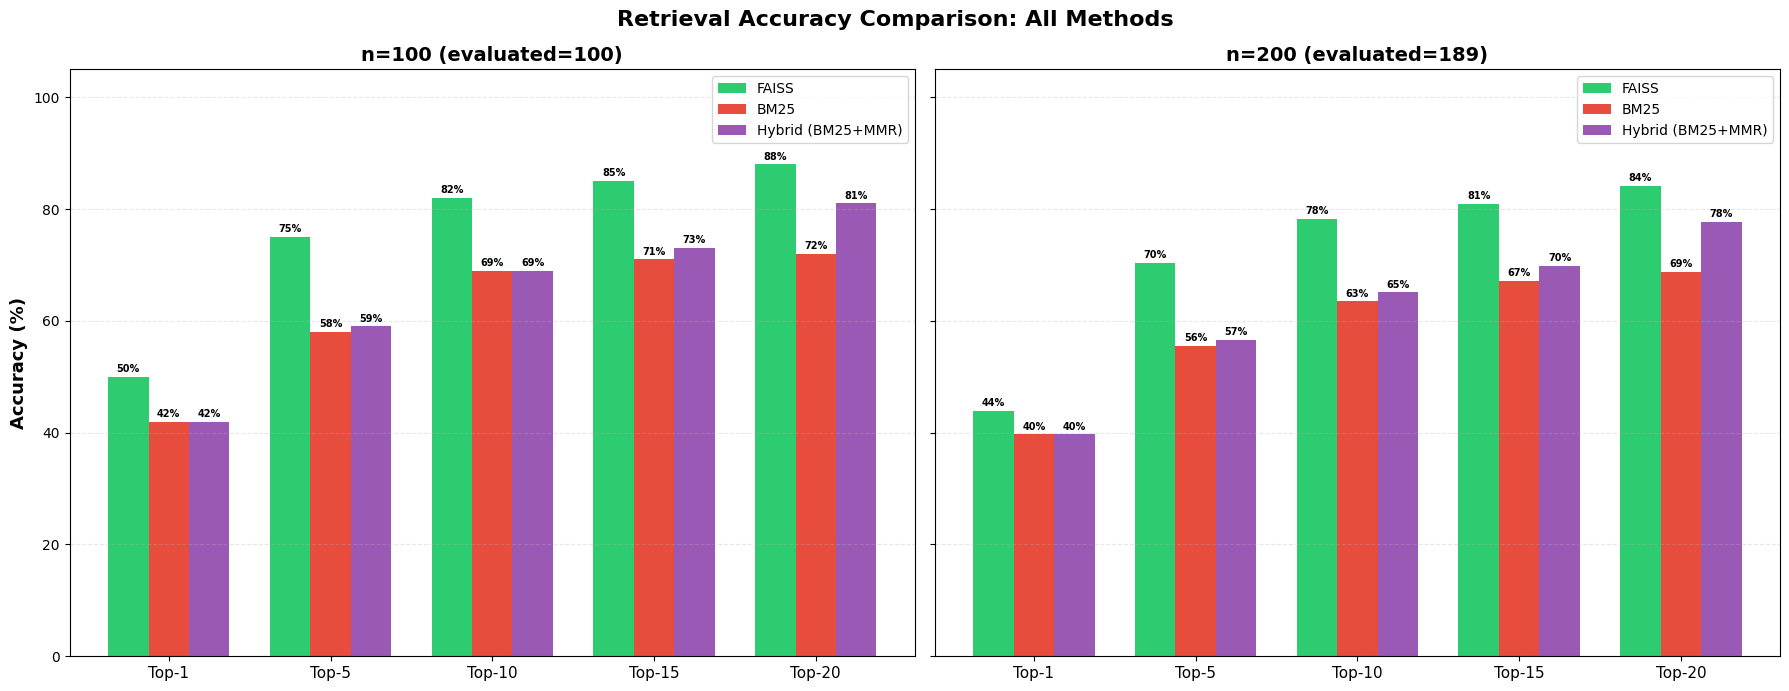

In [36]:
# Grouped bar chart: all 3 methods side-by-side at each k, one panel per n
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

method_names = list(METHODS.keys())
n_methods = len(method_names)
width = 0.25

for ax, n_label in zip(axes, ['n=100', 'n=200']):
    x = np.arange(len(K_VALUES))
    
    for i, method in enumerate(method_names):
        vals = [all_results[(method, n_label)][f'top_{k}'] for k in K_VALUES]
        offset = (i - n_methods/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=method, color=METHOD_COLORS[method])
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.0f}%',
                    ha='center', va='bottom', fontsize=7, fontweight='bold')
    
    n_eval = all_results[(method_names[0], n_label)]['total_evaluated']
    ax.set_title(f'{n_label} (evaluated={n_eval})', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Top-{k}' for k in K_VALUES], fontsize=11)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

axes[0].set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
plt.suptitle('Retrieval Accuracy Comparison: All Methods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

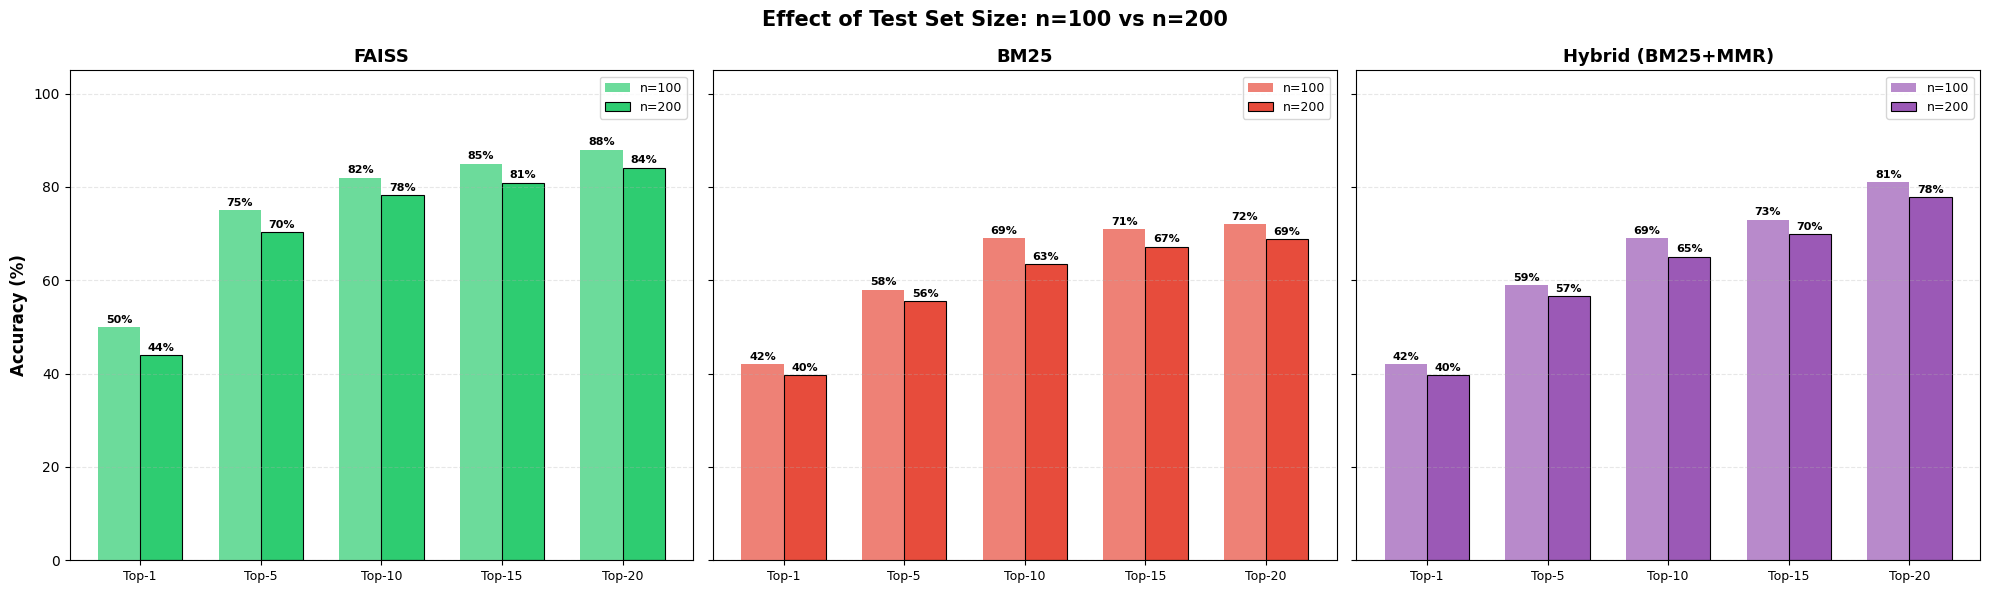

In [37]:
# Grouped bar chart: n=100 vs n=200 for each method at each k
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, method in zip(axes, METHODS):
    x = np.arange(len(K_VALUES))
    width = 0.35
    
    vals_100 = [all_results[(method, 'n=100')][f'top_{k}'] for k in K_VALUES]
    vals_200 = [all_results[(method, 'n=200')][f'top_{k}'] for k in K_VALUES]
    
    bars1 = ax.bar(x - width/2, vals_100, width, label='n=100', color=METHOD_COLORS[method], alpha=0.7)
    bars2 = ax.bar(x + width/2, vals_200, width, label='n=200', color=METHOD_COLORS[method], alpha=1.0,
                   edgecolor='black', linewidth=0.8)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.0f}%',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    ax.set_title(method, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Top-{k}' for k in K_VALUES], fontsize=9)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

axes[0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.suptitle('Effect of Test Set Size: n=100 vs n=200', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

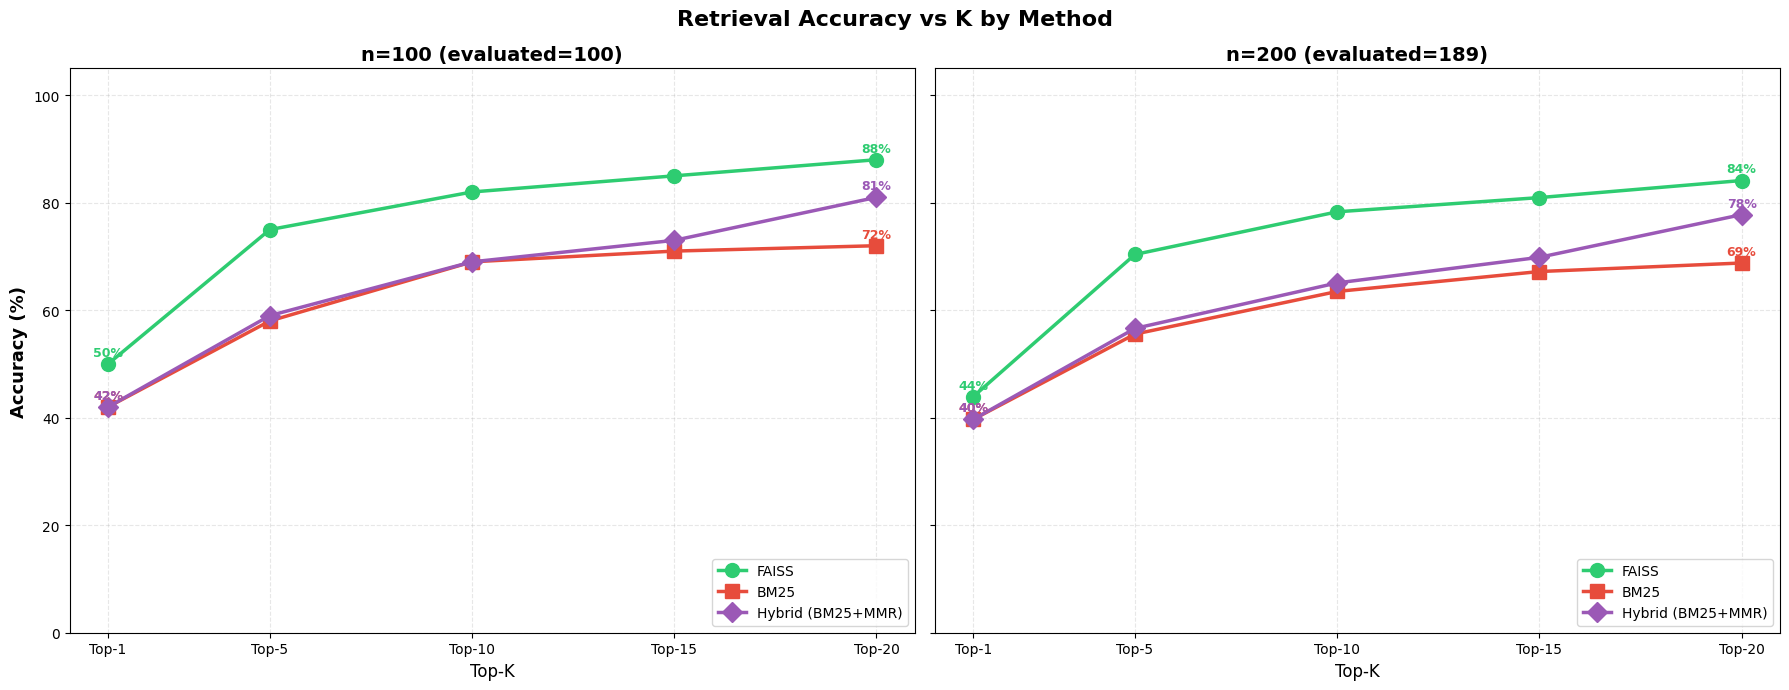

In [38]:
# Line plot: Accuracy vs K for each method, separate panels for n=100 and n=200
import matplotlib.pyplot as plt
import numpy as np

METHOD_COLORS = {'FAISS': '#2ecc71', 'BM25': '#e74c3c', 'Hybrid (BM25+MMR)': '#9b59b6'}
METHOD_MARKERS = {'FAISS': 'o', 'BM25': 's', 'Hybrid (BM25+MMR)': 'D'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, n_label in zip(axes, ['n=100', 'n=200']):
    for method in METHODS:
        results = all_results[(method, n_label)]
        vals = [results[f'top_{k}'] for k in K_VALUES]
        ax.plot(K_VALUES, vals, marker=METHOD_MARKERS[method], linewidth=2.5, markersize=10,
                label=method, color=METHOD_COLORS[method])
        # Label first and last points
        for idx in [0, -1]:
            ax.text(K_VALUES[idx], vals[idx] + 1.5, f'{vals[idx]:.0f}%',
                    ha='center', fontsize=9, color=METHOD_COLORS[method], fontweight='bold')
    
    n_eval = all_results[(list(METHODS.keys())[0], n_label)]['total_evaluated']
    ax.set_title(f'{n_label} (evaluated={n_eval})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Top-K', fontsize=12)
    ax.set_xticks(K_VALUES)
    ax.set_xticklabels([f'Top-{k}' for k in K_VALUES], fontsize=10)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=10, loc='lower right')

axes[0].set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
plt.suptitle('Retrieval Accuracy vs K by Method', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
# Save comprehensive results to JSON
save_data = {}
for (method, n_label), results in all_results.items():
    key = f"{method}_{n_label}"
    save_data[key] = {k: v for k, v in results.items()}

output_path = Path('retrieval_benchmark_results.json')
with output_path.open('w') as f:
    json.dump(save_data, f, indent=2)

print(f"Saved all benchmark results to {output_path}")

# Print full summary table
print("\n" + "="*120)
print("FULL BENCHMARK SUMMARY")
print("="*120)
header = f"{'Method':<22} {'n':>5}"
for k in K_VALUES:
    header += f"  {'Top-'+str(k):>8}"
print(header)
print("-"*120)
for (method, n_label), results in sorted(all_results.items(), key=lambda x: (x[0][0], x[0][1])):
    row = f"{method:<22} {n_label:>5}"
    for k in K_VALUES:
        row += f"  {results[f'top_{k}']:>7.1f}%"
    print(row)
print("="*120)

Saved all benchmark results to retrieval_benchmark_results.json

FULL BENCHMARK SUMMARY
Method                     n     Top-1     Top-5    Top-10    Top-15    Top-20
------------------------------------------------------------------------------------------------------------------------
BM25                   n=100     42.0%     58.0%     69.0%     71.0%     72.0%
BM25                   n=200     39.7%     55.6%     63.5%     67.2%     68.8%
FAISS                  n=100     50.0%     75.0%     82.0%     85.0%     88.0%
FAISS                  n=200     43.9%     70.4%     78.3%     81.0%     84.1%
Hybrid (BM25+MMR)      n=100     42.0%     59.0%     69.0%     73.0%     81.0%
Hybrid (BM25+MMR)      n=200     39.7%     56.6%     65.1%     69.8%     77.8%
